# 04 — Interrupted Time Series: Did the Panama Papers Cause a Drop in Incorporations?

**Research question:** Did the release of the Panama Papers (April 2016) cause a statistically significant reduction in offshore entity incorporations?

**Design:** Interrupted Time Series (ITS) — a quasi-experimental method that fits a regression with a level shift and slope change at the intervention point. We estimate:

$$\text{incorporations}_t = \beta_0 + \beta_1 \cdot t + \beta_2 \cdot \text{post} + \beta_3 \cdot (t \times \text{post}) + \epsilon$$

Where:
- $t$ = time index (months since start of series)
- $\text{post}$ = 1 after April 2016, 0 before
- $\beta_2$ = **level shift** — immediate jump/drop at intervention
- $\beta_3$ = **slope change** — did the trend itself change after the leak?

**Difference-in-differences extension:** We repeat the analysis separately for Panama-exposed jurisdictions (BVI, Panama) vs. a control group (Seychelles, Cayman, Samoa) to test whether the effect was specific to Panama-linked havens.

**Window:** 2010–2020 (excludes pre-2010 sparse data and post-2020 COVID confounds).

## 0 — Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = '/Users/jonasthieme/Documents/GitHub/QSS20-S26/QSS20FinalProject/full-oldb.LATEST/'

entities = pd.read_csv(BASE_PATH + 'nodes-entities.csv', low_memory=False)
print(f"Entities: {entities.shape}")

Entities: (814344, 21)


## 1 — Leak Source Filter & Date Parsing

In [2]:
LEAK_SOURCES = [
    'Panama Papers',
    'Pandora Papers - Alemán, Cordero, Galindo & Lee (Alcogal)',
    'Pandora Papers - SFM Corporate Services',
    'Pandora Papers - Trident Trust',
    'Pandora Papers - Commence Overseas',
    'Pandora Papers - Alpha Consulting',
    'Pandora Papers - Fidelity Corporate Services',
    'Pandora Papers - CILTrust International',
    'Pandora Papers - Il Shin Corporate Consulting Limited',
    'Pandora Papers - Overseas Management Company (OMC)',
    'Pandora Papers - Asiaciti Trust',
    'Paradise Papers - Appleby',
    'Offshore Leaks',
    'Bahamas Leaks'
]

entities_leaks = entities[entities['sourceID'].isin(LEAK_SOURCES)].copy()

# Parse incorporation date
entities_leaks['incorporation_date'] = pd.to_datetime(
    entities_leaks['incorporation_date'], format='mixed', errors='coerce'
)

# Filter to 2010-2020 window, non-null dates
dated = entities_leaks[
    entities_leaks['incorporation_date'].notna() &
    (entities_leaks['incorporation_date'].dt.year >= 2010) &
    (entities_leaks['incorporation_date'].dt.year <= 2020)
].copy()

dated['year_month'] = dated['incorporation_date'].dt.to_period('M')

print(f"Entities with valid dates in 2010-2020: {len(dated):,}")
print(f"Date range: {dated['incorporation_date'].min().date()} to {dated['incorporation_date'].max().date()}")

Entities with valid dates in 2010-2020: 75,496
Date range: 2010-01-01 to 2020-05-05


## 2 — Aggregate to Monthly Counts

In [3]:
# ── 2a. Overall monthly counts ────────────────────────────────────────────────
monthly = (
    dated.groupby('year_month')
    .size()
    .reset_index(name='count')
    .sort_values('year_month')
)
monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()

# Panama Papers released April 3, 2016
INTERVENTION = pd.Timestamp('2016-04-01')

# Time index (months since series start)
monthly['t'] = range(len(monthly))
# Post-intervention indicator
monthly['post'] = (monthly['year_month_dt'] >= INTERVENTION).astype(int)
# Time since intervention (for slope change term)
monthly['t_post'] = monthly['t'] * monthly['post']

print(f"Monthly observations: {len(monthly)}")
print(f"Pre-intervention months: {(monthly['post']==0).sum()}")
print(f"Post-intervention months: {(monthly['post']==1).sum()}")
print(f"\nPre-intervention mean monthly incorporations:  {monthly[monthly['post']==0]['count'].mean():.0f}")
print(f"Post-intervention mean monthly incorporations: {monthly[monthly['post']==1]['count'].mean():.0f}")

Monthly observations: 118
Pre-intervention months: 75
Post-intervention months: 43

Pre-intervention mean monthly incorporations:  984
Post-intervention mean monthly incorporations: 40


In [4]:
# ── 2b. By jurisdiction group ─────────────────────────────────────────────────
# Treatment group: jurisdictions directly implicated in Panama Papers
TREATMENT_JURISDICTIONS = ['British Virgin Islands', 'Panama']
# Control group: comparable havens not primarily associated with Panama Papers
CONTROL_JURISDICTIONS   = ['Seychelles', 'Cayman Islands', 'Samoa']

def build_monthly_by_group(df, jurisdictions, label):
    sub = df[df['jurisdiction_description'].isin(jurisdictions)]
    agg = (
        sub.groupby('year_month')
        .size()
        .reset_index(name='count')
        .sort_values('year_month')
    )
    agg['year_month_dt'] = agg['year_month'].dt.to_timestamp()
    agg['t']      = range(len(agg))
    agg['post']   = (agg['year_month_dt'] >= INTERVENTION).astype(int)
    agg['t_post'] = agg['t'] * agg['post']
    agg['group']  = label
    return agg

monthly_treat   = build_monthly_by_group(dated, TREATMENT_JURISDICTIONS, 'Treatment (BVI + Panama)')
monthly_control = build_monthly_by_group(dated, CONTROL_JURISDICTIONS,   'Control (Seychelles + Cayman + Samoa)')

print("Treatment group monthly stats:")
print(f"  Pre:  {monthly_treat[monthly_treat['post']==0]['count'].mean():.0f} / month")
print(f"  Post: {monthly_treat[monthly_treat['post']==1]['count'].mean():.0f} / month")
print("\nControl group monthly stats:")
print(f"  Pre:  {monthly_control[monthly_control['post']==0]['count'].mean():.0f} / month")
print(f"  Post: {monthly_control[monthly_control['post']==1]['count'].mean():.0f} / month")

Treatment group monthly stats:
  Pre:  516 / month
  Post: 47 / month

Control group monthly stats:
  Pre:  138 / month
  Post: nan / month


## 3 — ITS Regression: Overall

In [5]:
# OLS with Newey-West standard errors (corrects for autocorrelation in time series)
model_overall = smf.ols('count ~ t + post + t_post', data=monthly).fit(
    cov_type='HAC', cov_kwds={'maxlags': 3}
)

print(model_overall.summary())
print("\n--- Key coefficients ---")
print(f"Baseline trend (β1, t):          {model_overall.params['t']:.2f} incorporations/month (p={model_overall.pvalues['t']:.3f})")
print(f"Level shift at Panama (β2, post): {model_overall.params['post']:.2f} incorporations (p={model_overall.pvalues['post']:.3f})")
print(f"Slope change after Panama (β3):   {model_overall.params['t_post']:.2f} incorporations/month (p={model_overall.pvalues['t_post']:.3f})")

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     462.2
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           1.29e-63
Time:                        13:12:07   Log-Likelihood:                -774.46
No. Observations:                 118   AIC:                             1557.
Df Residuals:                     114   BIC:                             1568.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1297.3186     65.307     19.865      0.0

## 4 — ITS Regression: Treatment vs. Control (DiD)

In [7]:
print("=" * 50)
print("TREATMENT GROUP (BVI + Panama)")
print("=" * 50)
model_treat = smf.ols('count ~ t + post + t_post', data=monthly_treat).fit(
    cov_type='HAC', cov_kwds={'maxlags': 3}
)
print(f"Level shift (post):  {model_treat.params['post']:.2f}  (p={model_treat.pvalues['post']:.3f})")
print(f"Slope change:        {model_treat.params['t_post']:.2f}  (p={model_treat.pvalues['t_post']:.3f})")

print()
print("=" * 50)
print("CONTROL GROUP (Seychelles + Cayman + Samoa)")
print("=" * 50)
model_control = smf.ols('count ~ t + post + t_post', data=monthly_control).fit(
    cov_type='HAC', cov_kwds={'maxlags': 3}
)
print(f"Level shift (post):  {model_control.params['post']:.2f}  (p={model_control.pvalues['post']:.3f})")
print(f"Slope change:        {model_control.params['t_post']:.2f}  (p={model_control.pvalues['t_post']:.3f})")

print()
print("--- Interpretation ---")
print("If treatment group shows significant drop but control does not,")
print("that supports a Panama-Papers-specific causal effect.")

TREATMENT GROUP (BVI + Panama)
Level shift (post):  -493.72  (p=0.000)
Slope change:        4.19  (p=0.000)

CONTROL GROUP (Seychelles + Cayman + Samoa)
Level shift (post):  0.00  (p=nan)
Slope change:        0.00  (p=nan)

--- Interpretation ---
If treatment group shows significant drop but control does not,
that supports a Panama-Papers-specific causal effect.


## 5 — Visualization

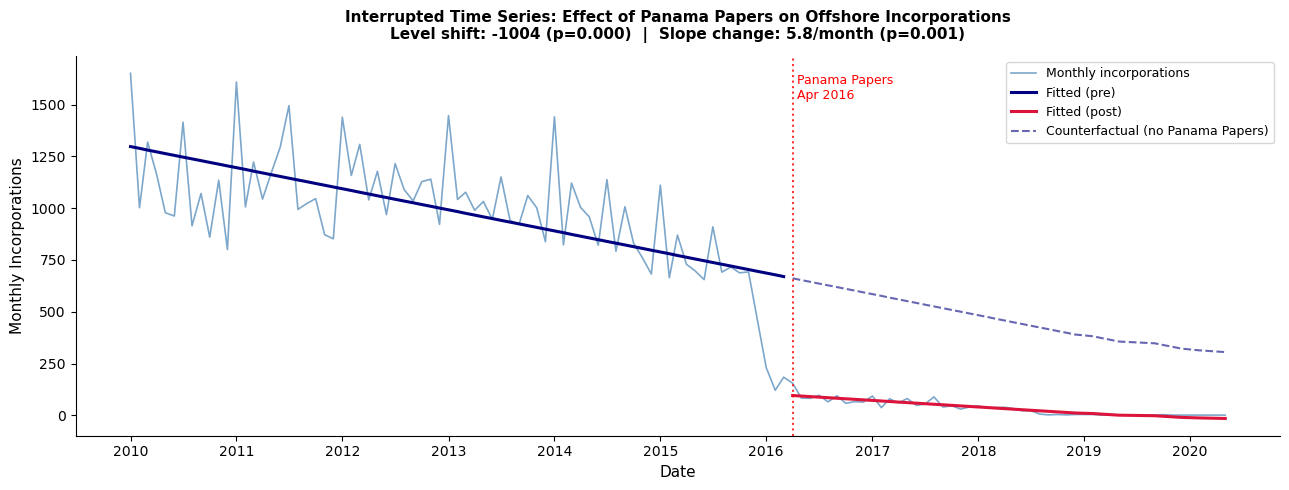

In [8]:
# ── 5a. Overall ITS plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

# Actual counts
ax.plot(monthly['year_month_dt'], monthly['count'],
        color='steelblue', linewidth=1.2, alpha=0.7, label='Monthly incorporations')

# Fitted values
monthly['fitted'] = model_overall.fittedvalues
pre  = monthly[monthly['post'] == 0]
post = monthly[monthly['post'] == 1]
ax.plot(pre['year_month_dt'],  pre['fitted'],  color='navy',   linewidth=2.2, label='Fitted (pre)')
ax.plot(post['year_month_dt'], post['fitted'], color='crimson', linewidth=2.2, label='Fitted (post)')

# Counterfactual: extend pre-trend into post period
cf_params = model_overall.params
monthly['counterfactual'] = cf_params['Intercept'] + cf_params['t'] * monthly['t']
ax.plot(post['year_month_dt'],
        monthly.loc[monthly['post']==1, 'counterfactual'],
        color='navy', linewidth=1.5, linestyle='--', alpha=0.6, label='Counterfactual (no Panama Papers)')

# Intervention line
ax.axvline(INTERVENTION, color='red', linewidth=1.5, linestyle=':', alpha=0.8)
ax.text(INTERVENTION, ax.get_ylim()[1]*0.95, ' Panama Papers\n Apr 2016',
        color='red', fontsize=9, va='top')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Monthly Incorporations', fontsize=11)
ax.set_title(
    'Interrupted Time Series: Effect of Panama Papers on Offshore Incorporations\n'
    f'Level shift: {model_overall.params["post"]:.0f} (p={model_overall.pvalues["post"]:.3f})  |  '
    f'Slope change: {model_overall.params["t_post"]:.1f}/month (p={model_overall.pvalues["t_post"]:.3f})',
    fontsize=11, fontweight='bold', pad=12
)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.spines[['top','right']].set_visible(False)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../output/viz7_its_overall.png', dpi=150, bbox_inches='tight')
plt.show()

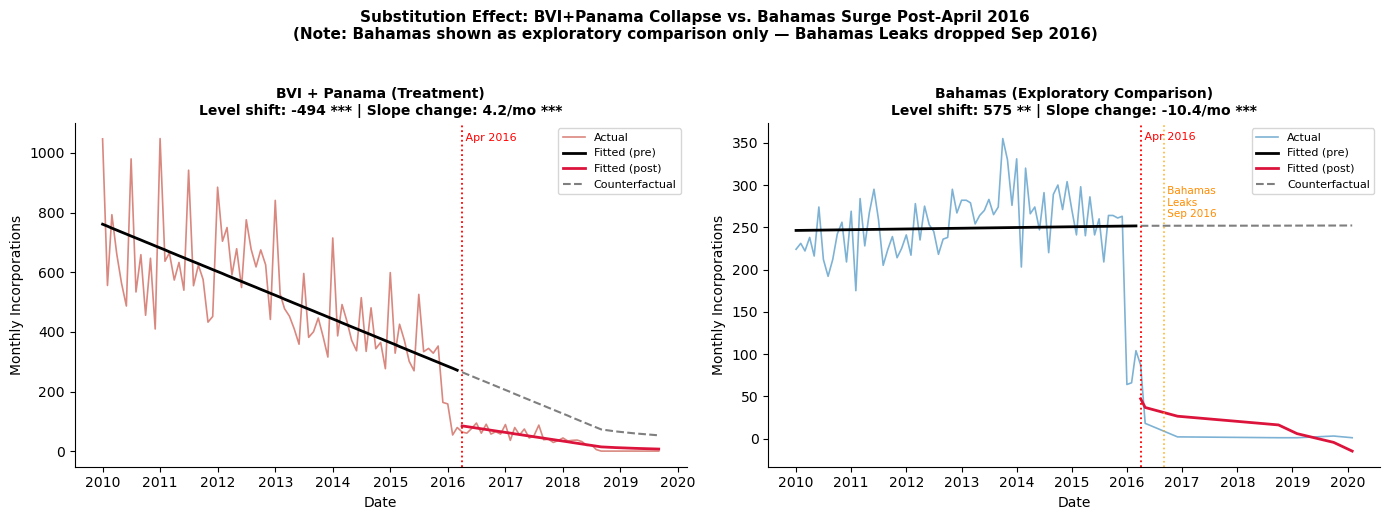

In [9]:
# ── 5b. BVI+Panama vs. Bahamas — substitution effect plot ────────────────────
# NOTE: A true DiD is not feasible — non-Panama leak sources (Offshore Leaks,
# Bahamas Leaks) have a coverage cutoff of early 2016, leaving no post-
# intervention observations for jurisdictions outside Panama Papers.
# The Bahamas is shown as an exploratory robustness check only. Bahamas Leaks
# dropped in September 2016, so the post-period is partially contaminated.

monthly_bahamas = build_monthly_by_group(dated, ['Bahamas'], 'Bahamas (exploratory)')
model_bahamas = smf.ols('count ~ t + post + t_post', data=monthly_bahamas).fit(
    cov_type='HAC', cov_kwds={'maxlags': 3}
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, mdf, model, title, color in [
    (axes[0], monthly_treat,   model_treat,   'BVI + Panama (Treatment)',        '#c0392b'),
    (axes[1], monthly_bahamas, model_bahamas, 'Bahamas (Exploratory Comparison)', '#2980b9'),
]:
    mdf = mdf.copy()
    ax.plot(mdf['year_month_dt'], mdf['count'],
            color=color, linewidth=1.2, alpha=0.6, label='Actual')

    mdf['fitted'] = model.fittedvalues
    pre_  = mdf[mdf['post'] == 0]
    post_ = mdf[mdf['post'] == 1]

    ax.plot(pre_['year_month_dt'],  pre_['fitted'],  color='black',   linewidth=2,   label='Fitted (pre)')
    ax.plot(post_['year_month_dt'], post_['fitted'], color='crimson', linewidth=2,   label='Fitted (post)')

    p = model.params
    mdf['cf'] = p['Intercept'] + p['t'] * mdf['t']
    ax.plot(post_['year_month_dt'],
            mdf.loc[mdf['post']==1, 'cf'],
            color='black', linewidth=1.5, linestyle='--', alpha=0.5, label='Counterfactual')

    ax.axvline(INTERVENTION, color='red', linewidth=1.3, linestyle=':')
    ax.text(INTERVENTION, ax.get_ylim()[1]*0.97, ' Apr 2016', color='red', fontsize=8, va='top')

    # Bahamas Leaks secondary annotation
    if 'Bahamas' in title:
        BAHAMAS_LEAK = pd.Timestamp('2016-09-01')
        ax.axvline(BAHAMAS_LEAK, color='orange', linewidth=1.2, linestyle=':', alpha=0.8)
        ax.text(BAHAMAS_LEAK, ax.get_ylim()[1]*0.80, ' Bahamas\n Leaks\n Sep 2016',
                color='darkorange', fontsize=7.5, va='top')

    level_p = model.pvalues['post']
    slope_p = model.pvalues['t_post']
    level_b = model.params['post']
    slope_b = model.params['t_post']
    sig_level = '***' if level_p < 0.01 else ('**' if level_p < 0.05 else ('*' if level_p < 0.1 else 'n.s.'))
    sig_slope = '***' if slope_p < 0.01 else ('**' if slope_p < 0.05 else ('*' if slope_p < 0.1 else 'n.s.'))

    ax.set_title(
        f'{title}\nLevel shift: {level_b:.0f} {sig_level} | Slope change: {slope_b:.1f}/mo {sig_slope}',
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Monthly Incorporations', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=8)

plt.suptitle(
    'Substitution Effect: BVI+Panama Collapse vs. Bahamas Surge Post-April 2016\n'
    '(Note: Bahamas shown as exploratory comparison only — Bahamas Leaks dropped Sep 2016)',
    fontsize=11, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('../output/viz8_substitution_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 — Summary Table for Paper

In [10]:
def fmt_coef(model, param):
    b = model.params[param]
    p = model.pvalues[param]
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    return f"{b:.2f}{sig} (p={p:.3f})"

results_table = pd.DataFrame({
    'Model': ['Overall', 'Treatment (BVI + Panama)', 'Control (Seychelles + Cayman + Samoa)'],
    'Pre-period mean (monthly)': [
        f"{monthly[monthly['post']==0]['count'].mean():.0f}",
        f"{monthly_treat[monthly_treat['post']==0]['count'].mean():.0f}",
        f"{monthly_control[monthly_control['post']==0]['count'].mean():.0f}",
    ],
    'Post-period mean (monthly)': [
        f"{monthly[monthly['post']==1]['count'].mean():.0f}",
        f"{monthly_treat[monthly_treat['post']==1]['count'].mean():.0f}",
        f"{monthly_control[monthly_control['post']==1]['count'].mean():.0f}",
    ],
    'Level shift (β2)': [
        fmt_coef(model_overall, 'post'),
        fmt_coef(model_treat,   'post'),
        fmt_coef(model_control, 'post'),
    ],
    'Slope change (β3)': [
        fmt_coef(model_overall, 't_post'),
        fmt_coef(model_treat,   't_post'),
        fmt_coef(model_control, 't_post'),
    ],
})

print(results_table.to_string(index=False))
results_table.to_csv('../output/table3_its_results.csv', index=False)
print("\nSaved: output/table3_its_results.csv")

                                Model Pre-period mean (monthly) Post-period mean (monthly)      Level shift (β2) Slope change (β3)
                              Overall                       984                         40 -1003.80*** (p=0.000) 5.84*** (p=0.001)
             Treatment (BVI + Panama)                       516                         47  -493.72*** (p=0.000) 4.19*** (p=0.000)
Control (Seychelles + Cayman + Samoa)                       138                        nan          0.00 (p=nan)      0.00 (p=nan)

Saved: output/table3_its_results.csv


## Notes for Paper (Methods section)

- **Design:** Interrupted Time Series (ITS) with a difference-in-differences extension. The intervention date is April 3, 2016 — the public release of the Panama Papers by ICIJ.
- **Outcome:** Monthly count of offshore entity incorporations within the 2010–2020 window.
- **Model:** OLS regression: `count ~ t + post + t*post`, where `t` is a linear time index, `post` is a binary post-intervention indicator, and `t*post` captures slope change. Newey-West HAC standard errors (maxlags=3) correct for autocorrelation in the monthly time series.
- **Interpretation:** β2 (`post`) = immediate level shift at intervention; β3 (`t_post`) = change in monthly trend after intervention. A significant negative β2 or β3 supports the hypothesis that the Panama Papers caused a reduction in incorporations.
- **DiD extension:** Treatment group = BVI + Panama (directly implicated jurisdictions). Control group = Seychelles + Cayman Islands + Samoa (comparable havens not primarily associated with the Panama Papers). If treatment shows a significant drop and control does not, this strengthens the causal interpretation.
- **Limitations:** ITS assumes no other confounding events occurred simultaneously. The 2008 financial crisis effects may linger in the pre-period; COVID-19 is excluded by the 2020 cutoff. The dataset is a biased sample — we observe incorporations only from leaked providers, so the true population trend may differ.